In [8]:
"""
Модель Hovorka.

"""

import numpy as np
from scipy.integrate import odeint
from scipy.integrate import ode
from scipy.optimize import fsolve


def hovorka_parameters(BW):
    """Функция, возвращающая параметры модели Ховорки для заданного веса тела"""
    V_I = 0.12*BW              # Объем распределения инсулина [L]
    V_G = 0.16*BW              # Объем распределения глюкозы [L]
    F_01 = 0.0097*BW           # Неконтролируемый поток глюкозы [mmol/min]
    EGP_0 = 0.0161*BW          # Производство глюкозы печенью при нулевой концентрации инсулина [mmol/min]

    # Независимые от пациента параметры
    S_IT = 51.2e-4             # Чувствительность инсулина при транспортировке [L/min*mU]
    S_ID = 8.2e-4              # Чувствительность инсулина при утилизации [L/min*mU]
    S_IE = 520e-4              # Чувствительность инсулина при производстве глюкозы [L/mU]

    tau_G = 40                 # Время до максимального поглощения углеводов [мин]
    tau_I = 55                 # Время до максимального поглощения инсулина [мин]

    A_G = 0.8                  # Биодоступность углеводов [1]
    k_12 = 0.066               # Скорость переноса [мин^-1]

    k_a1 = 0.006               # Скорость деактивации инсулина при транспортировке [мин^-1]
    k_b1 = S_IT * k_a1         # Скорость активации инсулина при транспортировке
    k_a2 = 0.06                # Скорость деактивации инсулина при утилизации [мин^-1]
    k_b2 = S_ID * k_a2         # Скорость активации инсулина при утилизации
    k_a3 = 0.03                # Скорость деактивации инсулина при производстве глюкозы [мин^-1]
    k_b3 = S_IE * k_a3         # Скорость активации инсулина при производстве глюкозы

    k_e = 0.138                # Элиминация инсулина из плазмы [мин^-1]

    # Возвращаем все параметры в виде списка
    return [tau_G, tau_I, A_G, k_12, k_a1, k_b1, k_a2, k_b2, k_a3, k_b3, k_e, V_I, V_G, F_01, EGP_0]

def hovorka_model(t, x, u, D, P): #####x t
    """Модель Ховорки для решения ОДУ"""
    #print("Input x:", len(x))  # Отладочный вывод

    D1, D2, S1, S2, Q1, Q2, I, x1, x2, x3, C = x

    tau_G, tau_I, A_G, k_12, k_a1, k_b1, k_a2, k_b2, k_a3, k_b3, k_e, V_I, V_G, F_01, EGP_0 = P

    U_G = D2/tau_G             # Скорость поглощения глюкозы [mmol/min]
    U_I = S2/tau_I             # Скорость поглощения инсулина [mU/min]

    G = Q1/V_G                 # Концентрация глюкозы [mmol/L]

    if G >= 4.5:
        F_01c = F_01           # Потребление глюкозы ЦНС [mmol/min]
    else:
        F_01c = F_01 * G / 4.5

    if G >= 9:
        F_R = 0.003 * (G - 9) * V_G  # Почечная экскреция глюкозы [mmol/min]
    else:
        F_R = 0
        
    # Mass balances/differential equations
    xdot = np.zeros (11);

    xdot[ 0 ] = A_G*D-D1/tau_G                                # dD1
    xdot[ 1 ] = D1/tau_G-U_G                                  # dD2
   
    xdot[ 2 ] = u-S1/tau_I                                    # dS1
    xdot[ 3 ] = S1/tau_I-U_I                                  # dS2
   
    xdot[ 4 ] = -(F_01c+F_R) - x1*Q1 + k_12*Q2 + U_G + max(EGP_0*(1-x3), 0)   # dQ1
    xdot[ 5 ] = x1*Q1-(k_12+x2)*Q2                            # dQ2

    xdot[ 6 ] = U_I/V_I-k_e*I                                 # dI
    
    xdot[ 7 ] = k_b1*I-k_a1*x1                                # dx1
    xdot[ 8 ] = k_b2*I-k_a2*x2                                # dx2
    xdot[ 9 ] = k_b3*I-k_a3*x3                                # dx3

    # ===============
    # CGM delay
    # ===============
    ka_int = 0.073

    xdot[10] = ka_int*(G - C)


    return xdot

def hovorka_model_tuple(x, *pars):
    """HOVORKA DIFFERENTIAL EQUATIONS without time variable
    # t:    Time window for the simulation. Format: [t0 t1], or [t1 t2 t3 ... tn]. [min]
    # x:    Initial conditions
    # u:    Amount of insulin insulin injected [mU/min]
    # D:    CHO eating rate [mmol/min]
    # P:    Model fixed parameters
    #
    """
    u, D, P = pars
    t = 0
    xdot = hovorka_model(t, x, u, D, P)
    return xdot

def simulate_glucose_concentrationHOV(total_time, BW, meals: list, meal_indicator: list, basal):
    """Симуляция концентрации глюкозы через заданное время."""
    # Получаем параметры модели для заданного веса тела
    P = hovorka_parameters(BW)  
    initial_pars = (basal, 0, P)
    x0 = fsolve(hovorka_model_tuple, np.zeros(11), args=initial_pars) ##Определение начального состояния
    print("init bg ", x0[4]/P[12] * 18)
    
    timeline = np.arange(0, total_time, 1)

    BG = []
    BG.append(x0[4]/P[12] * 18)
    X = ode(hovorka_model)
    X.set_integrator('dopri5')
    X.set_initial_value(x0, 0).set_f_params(0, 0, P)

    while X.successful() and X.t < total_time-1:  ##-1 т.к посчитали начальное состояние
        insulin_rate =  basal + meal_indicator[int(X.t)]
        X.set_f_params(insulin_rate, meals[int(X.t)], P)
        solver = X.integrate(X.t + 1)
        BG.append(solver[4]/P[12] * 18) #mmol/l ->mg/dl

    return BG


def distribute_actionHOV(ACT, TIME, total_time):
    meal_timeline = np.zeros(total_time)
    
    # Вставляем значения из ACT в соответствующие моменты времени из списка TIME
    for act, t in zip(ACT, TIME):
        meal_timeline[t] = act
    
    return meal_timeline



In [9]:
"""
Модель Simglucose.

"""
import pandas as pd
import numpy as np
from scipy.integrate import ode


patient_params = pd.read_csv("vpatient_params.csv")
params = patient_params.loc[patient_params.Name == "adolescent#001"].squeeze()
init_state = np.copy(params.iloc[2:15].values)
sensor_params = pd.read_csv("sensor_params.csv")
sensor_params = sensor_params.loc[sensor_params.Name == "Dexcom"].squeeze()



def johnson_transform_SU(xi, lam, gamma, delta, x):##Пока шум не добавляю
    return xi + lam * np.sinh((x - gamma) / delta)

# Функция генерации шума
def generate_noise(params, seed=42):
    rand_gen = np.random.RandomState(seed)
    e = rand_gen.randn()
    eps = johnson_transform_SU(params["xi"], params["lambda"], params["gamma"], params["delta"], e)
    return eps



# Определяем уравнения для модели T1D, используя параметры
def t1d_model(t, x, action, params):


    dxdt = np.zeros(13)
    d = action["CHO"] * 1000 # g -> mg
    insulin = action["insulin"] * 6000 / params.BW # U/min -> pmol/kg/min
    basal = params.u2ss * params.BW / 6000 # U/min
    
    qsto = x[0] + x[1] # Glucose in the stomach
     
    dxdt[0] = -params.kmax * x[0] + d # Stomach solid
    
    Dbar = 0 #Можно переделать
    kgut = params.kmax
    dxdt[1] = params.kmax * x[0] - x[1] * kgut # stomach liquid
    dxdt[2] = kgut * x[1] - params.kabs * x[2] # intestine
    
    # Rate of appearance
    Rat = params.f * params.kabs * x[2] / params.BW
    # Glucose Production
    EGPt = params.kp1 - params.kp2 * x[3] - params.kp3 * x[8]
    # Glucose Utilization
    Uiit = params.Fsnc
    
    # renal excretion
    if x[3] > params.ke2:
        Et = params.ke1 * (x[3] - params.ke2)
    else:
        Et = 0


    # glucose kinetics
    # plus dextrose IV injection input u[2] if needed
    dxdt[3] = max(EGPt, 0) + Rat - Uiit - Et - params.k1 * x[3] + params.k2 * x[4]
    dxdt[3] = (x[3] >= 0) * dxdt[3]

    Vmt = params.Vm0 + params.Vmx * x[6]
    Kmt = params.Km0
    Uidt = Vmt * x[4] / (Kmt + x[4])
    dxdt[4] = -Uidt + params.k1 * x[3] - params.k2 * x[4]
    dxdt[4] = (x[4] >= 0) * dxdt[4]

    # insulin kinetics
    dxdt[5] = (
        -(params.m2 + params.m4) * x[5]
        + params.m1 * x[9]
        + params.ka1 * x[10]
        + params.ka2 * x[11]
    )  # plus insulin IV injection u[3] if needed
    It = x[5] / params.Vi
    dxdt[5] = (x[5] >= 0) * dxdt[5]

    # insulin action on glucose utilization
    dxdt[6] = -params.p2u * x[6] + params.p2u * (It - params.Ib)

    # insulin action on production
    dxdt[7] = -params.ki * (x[7] - It)

    dxdt[8] = -params.ki * (x[8] - x[7])

    # insulin in the liver (pmol/kg)
    dxdt[9] = -(params.m1 + params.m30) * x[9] + params.m2 * x[5]
    dxdt[9] = (x[9] >= 0) * dxdt[9]

    # subcutaneous insulin kinetics
    dxdt[10] = insulin - (params.ka1 + params.kd) * x[10]
    dxdt[10] = (x[10] >= 0) * dxdt[10]

    dxdt[11] = params.kd * x[10] - params.ka2 * x[11]
    dxdt[11] = (x[11] >= 0) * dxdt[11]

    # subcutaneous glucose
    dxdt[12] = -params.ksc * x[12] + params.ksc * x[3]
    dxdt[12] = (x[12] >= 0) * dxdt[12]

    return dxdt



# Функция для прогнозирования уровня глюкозы
def simulate_glucose_concentration(total_time, initial_state, params, CHO, INS, basal):
    # Делаем равномерное распределение CHO и INS по времени
    
    # Переменная для хранения уровней глюкозы
    glucose_levels = []
    current_state = initial_state.copy()  # Начальное состояние системы
    # ODE Solver
    solver = ode(t1d_model).set_integrator('dopri5')
    # Проходим по каждому временному шагу (по одной минуте)
    for t in range(total_time):
        # Вводим CHO и INS для текущего шага
        action = {"CHO": CHO[t], "insulin": INS[t] + basal}
        
        # Обновляем начальные условия для интегратора
        solver.set_initial_value(current_state, 0)
        solver.set_f_params(action, params)
        
        # Интегрируем на 1 минуту вперед
        solver.integrate(solver.t + 1)
        
        # Получаем предсказанный уровень глюкозы и сохраняем его
        predicted_glucose = solver.y[12] / params.Vg
        glucose_levels.append(predicted_glucose)
        
        # Обновляем текущее состояние системы для следующей итерации
        current_state = solver.y

    return glucose_levels
    
def distribute_action(ACT, TIME, total_time):
    meal_timeline = np.zeros(total_time)
    
    # Вставляем значения из ACT в соответствующие моменты времени из списка TIME
    for act, t in zip(ACT, TIME):
        meal_timeline[t] = act
    
    return meal_timeline

def extend_values(arr, times, repetitions=2): #В SIMGLUCOSE INS и CHO активны 3 минуты. Продлеваю CHO, INS еще на 2 минуты
    for time in times:
        for i in range(1, repetitions + 1):
            if time + i < len(arr):
                arr[time + i] = arr[time]
    return arr
    


In [10]:
def generation(total_time, BW, CHO: list, INS: list, CHO_TIME: list, INS_TIME: list):
    """
    Функция для генерации данных.

    Параметры:
    - total_time: время генерации.
    - BW: вес человека.
    - CHO: list подачи углеводов.
    - INS: list подачи инсулина.
    - CHO_time list времен подачи
    """
    
    ##Simglucose
    #CHO в граммах,  INS в U(unit)
    CHO_sim = (i*3 for i in CHO)  #*3 из структуры simglucose
    INS_sim = (i*3 for i in INS)
    CHO_sim = distribute_action(CHO_sim, CHO_TIME, total_time) #Переводим в list len(total_time)
    INS_sim = distribute_action(INS_sim, INS_TIME, total_time)
    basal_sim = params.u2ss * params.BW / 6000 # U/min   
    glucose_levels_sim = simulate_glucose_concentration(total_time=total_time, initial_state=init_state, params=params, CHO=CHO_sim, INS=INS_sim, basal=basal_sim)


    #Hovorka
    #CHO в mmol,  INS в mU
    mmol = 1000/180.16 #Перевод в mmol
    CHO_hov = (mmol*i for i in CHO)
    const= 1000
    INS_hov = (const*i for i in INS) #U/min -> mU/min
    
    CHO_hov = distribute_actionHOV(CHO_hov, CHO_TIME, total_time)
    INS_hov = distribute_actionHOV(INS_hov, INS_TIME, total_time)
    basal_hov = 5.96 #Используется для определения начального состояние + постоянно вводится дополнительно action
    glucose_levels_hov = simulate_glucose_concentrationHOV(total_time, BW, CHO_hov, INS_hov, basal_hov)

    
    INS_BAS = (i+basal_hov for i in INS_hov)
    df_hov = pd.DataFrame({
        'BG': glucose_levels_hov,
        'CHO': CHO_hov,
        'INS': INS_BAS
    })
    df_hov.to_csv('datatest_hov1.csv', index=False)

    
    INS_sim_BAS = (i+basal_sim for i in INS_sim)
    df_sim = pd.DataFrame({
        'BG': glucose_levels_sim,
        'CHO': CHO_sim,
        'INS': INS_sim_BAS
    })
    df_sim.to_csv('datatest_sim1.csv', index=False)
    
    return glucose_levels_sim, glucose_levels_hov

def graph_output(total_time, glucose_levels, glucose_levels_hov):
    # Создаем временной массив для оси X (общий для обоих графиков)
    time_points = np.arange(0, total_time)

    # Построение графика
    plt.figure(figsize=(12, 6))

    # Добавляем линию из первой подпрограммы (HOVORKA)
    plt.plot(time_points, glucose_levels_hov[:len(time_points)], label='Glucose HOVORKA (mg/dL)', color='blue')

    # Добавляем линию из второй подпрограммы (SIMGLUCOSE)
    plt.plot(time_points, glucose_levels[:len(time_points)], label='Glucose SIMGLUCOSE (mg/dL)', color='red')

    # Оформление графика
    plt.title('Сравнение уровня глюкозы по двум моделям')
    plt.xlabel('Время (минуты)')
    plt.ylabel('Уровень глюкозы (mg/dL)')
    plt.legend()
    plt.grid(True)

    # Показываем график
    plt.show()

init bg  149.1517204057262


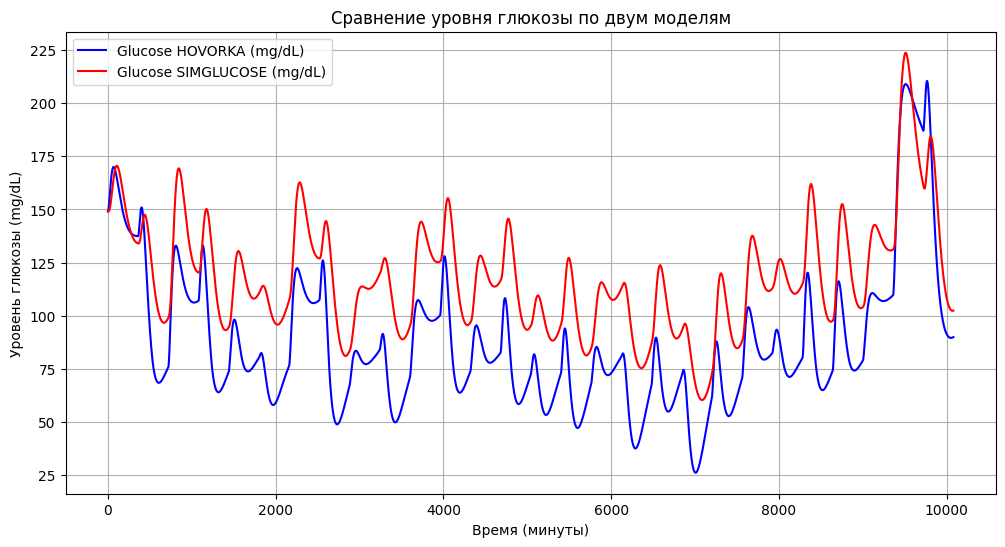

In [11]:
import matplotlib.pyplot as plt
import numpy as np

#-----------SIMGLUCOSE-------#
#Изменяемые параметры
total_time=60*24*7#min  
BW=70 #kg
#CHO = [11.1, 11.8, 2.6] #g  #Данные взяты из шаблона Simglucose
#INS = [0.94 , 1.19, 0.23]#U/min (Вроде бы)
#CHO_TIME = [520, 640, 870]
#INS_TIME = [520, 640, 870]


for i in range(1):
    # Генерация случайных значений CHO и INS. Надо добавить зависимость CHO INS
    CHO = np.random.uniform(2, 30.01, 28)  # Значения углеводов в диапазоне 5-30 g
    INS = np.random.uniform(0.2, 2.5, 28)  # Значения инсулина в диапазоне 0.5-2.5 U
    
    TIME = [i*360 for i in range(28)]#Каждые 6 часов подача
    #print(TIME)
    CHO_TIME = TIME
    INS_TIME = TIME
    # Генерация уровня глюкозы
    glucose_levels, glucose_levels_hov = generation(total_time, BW, CHO, INS, CHO_TIME, INS_TIME)
    
    # Вывод графика для каждой итерации
    graph_output(total_time, glucose_levels, glucose_levels_hov)

